### Introduction to Audio and Music Processing (CH-EAM-B)
# 06 - Time-Frequency-Transformations 1

Prof. Dr. Jakob Abeßer (jakob.abesser@uni-bamberg.de)

Last update: 18.05.2026

## Learning Objectives

- Study effect of different sample rates
- Study effect of different quantization bit depths
- Study influence of hopsize and window size on STFT
- Logarithmic compression of STFT magnitude spectrograms

## Audio Material

We are again using free instrument note samples provided by the Philharmonia_Orchestra_Library (https://philharmonia.co.uk/resources/sound-samples/)


We have three sound examples of notes with different pitches for the 5 instruments 
- Bass clarinet
- Bassoon
- Cello
- Flute
- French Horn


In [1]:
!pip install wget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import wget
import zipfile
import os
import glob

import librosa
import librosa.display
import soundfile as sf

from pathlib import Path
from IPython.display import Audio, display, Markdown

In [3]:
# download zip file (if it has been downloaded already)
if not os.path.isfile('CH-EAM-B-Seminar-05_sounds.zip'):
    print('Please wait a couple of seconds ...')
    wget.download('https://github.com/CHBamberg/CH-EAM-B-SS-2026/raw/refs/heads/main/data/CH-EAM-B-Seminar-05_sounds.zip', 
                      out='CH-EAM-B-Seminar-05_sounds.zip', bar=None)
    print('CH-EAM-B-Seminar-05_sounds.zip downloaded successfully ...')
else:
    print('Files already exist!')

# if at least one of the audio files does not exist -> unzip zip file
if not os.path.isfile('cello_A2_1_fortissimo_arco-normal.wav'):
    print("Let's unzip the file ... ")
    assert os.path.isfile('CH-EAM-B-Seminar-05_sounds.zip')
    with zipfile.ZipFile('CH-EAM-B-Seminar-05_sounds.zip', 'r') as f:
        f.extractall('.')
        
    print("All done :)")
else:
    print('All audio files exist.')
    
dir_wav = 'CH-EAM-B-Seminar-05_sounds'

Files already exist!
Let's unzip the file ... 
All done :)


## Helper Functions

In [4]:
def show_audio(y, sr, label=None):
    """ Show playback button to listen to audio file
    Args:
        y (np.ndarray): Audio samples
        sr (float): Sample rate (in Hz)
        label (str): Optional label
    """
    if label is not None:
        display(Markdown(f"**{label}**"))
    display(Audio(y, rate=sr, normalize=False))
    
def plot_waveform(y, sr, start_s=0.0, end_s=None, title="Waveform"):
    """ Plot waveform of audio recording or a segment thereof
    Args:
        y (np.ndarray): Audio samples
        sr (float): Sample rate (in Hz)
        start_s (float): Segement start (in s)
        end_s (float): Segment end (in s), if None: end of the file is used
        title (str): optional figure title
    """
    start = int(start_s * sr)
    end = len(y) if end_s is None else int(end_s * sr)
    end = min(end, len(y))
    start = max(0, start)

    t = np.arange(start, end) / sr

    plt.figure(figsize=(10, 2.5))
    plt.plot(t, y[start:end], linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.tight_layout()
    plt.show()


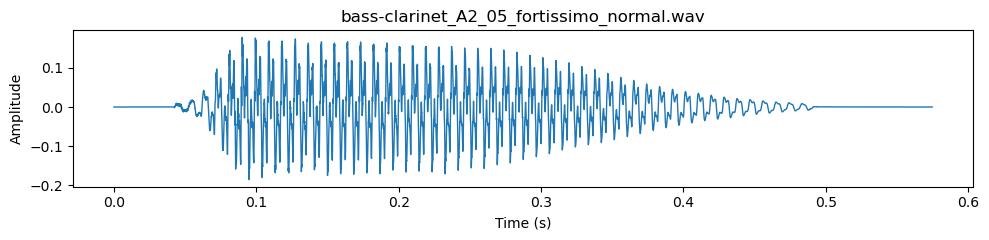

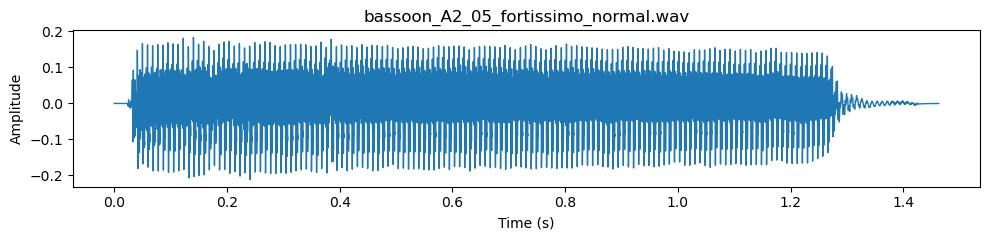

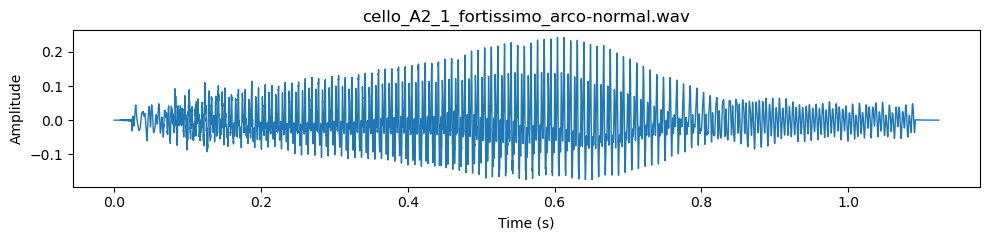

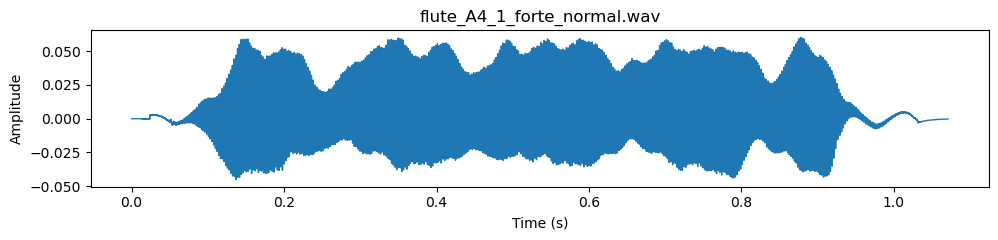

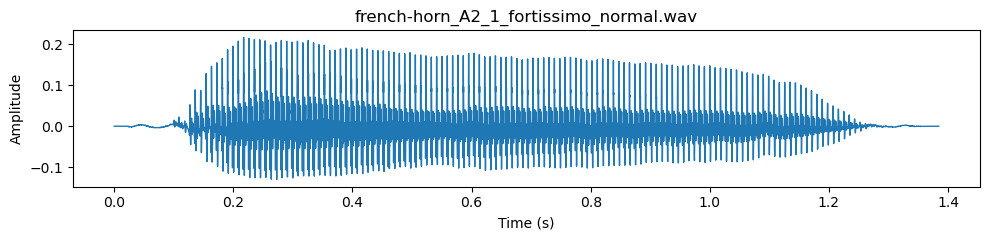

In [5]:
# Let's listen to the audio files
fn_list = ('bass-clarinet_A2_05_fortissimo_normal.wav',
           'bassoon_A2_05_fortissimo_normal.wav',
           'cello_A2_1_fortissimo_arco-normal.wav',
           'flute_A4_1_forte_normal.wav',
           'french-horn_A2_1_fortissimo_normal.wav')
for fn_wav in fn_list:
    x, fs = librosa.load(os.path.join(dir_wav, fn_wav), sr=None)
    plot_waveform(x, fs, title=os.path.basename(fn_wav))
    show_audio(x, fs)

## 1) Sample rate

Let us use **flute_A4_1_forte_normal.wav** as an example to investigate how the sample rate and the perceived quality of the audio signal.

In [28]:
# TASK 1) Modify the code cell above: iterate over the sample rates (44100, 22050, 10000, 5000) and 
#         create the waveform plot and play widget for the 'flute_A4_1_forte_normal.wav' at 
#         different sample rates
sample_rates = (44100, 22050, 10000, 5000)
for sr in sample_rates:
    # TODO implement
    pass

**Observation**: How does the sound changes? What is the reason?

## 2) Quantization

Now we want to investigate the influence of the quantization depth. 

Remember, if we have $b=16$ bit, this gives us $2^{16}=65536$ quantization between $-1$ and $1$, which is the full digital range of audio.

In [30]:
# Task 2a) Implement a function that applies the quantization
def quantize_audio(x, n_bits):
    """ Simulates quantizing the values in x with a pre-defined bit depth.
    Args:
        x (np.ndarray): Audio signal
        n_bits (int): Bit depth
    """
    # Calculate the maximum level for the target bit depth
    # For signed audio, we have 2^(bits - 1) levels for positive and negative ranges
    # TODO implement
    levels = None # TODO implement 
    
    # Scale up, round to nearest integer to simulate quantization, then scale back down
    x = None # TODO implement 
    
    return x

In [29]:
# Task 2b) Try it on 'flute_A4_1_forte_normal.wav' (with a sample rate of 44.1 kHz)
n_bits = (16,12,8,5)
for n_b in n_bits:
    pass # TODO implement

**Observation**: How does the sound changes? What is the reason?

## 3) Short-time Fourier Transform (STFT)

Now, we will convert an audio file into a magnitude spectrogram, to study the frequency components, it is made of.
In particular, we want to investigate, how the **window size** and **hop size** of the **Short-time Fourier Transform (STFT)** affects the temporal and frequency resolution.

In [19]:
# let us focus on the french horn note for now
fn = 'french-horn_A2_1_fortissimo_normal.wav'

In [31]:
# Task 3a: 
# - Compute the STFT (using the librosa library) using a hopsize of 512 and a window size of 2048
# - use the librosa.display.specshow() command to visualize a spectrogram with the x-axis being the time 
#   in seconds and the y-axis being the frequency in Hz
n_fft = 2048
hop_length = 512
x, fs = librosa.load(os.path.join(dir_wav, fn), sr=None)

# TODO implement

**Observations**
- What do you observe? How many overtones can you see? Do you expect more?

In [32]:
# Task 3b:
# - apply a logarithmic compression and convert the (linear) magnitude values of the STFT to 
#   dB (decibels), and plot again
# - hint: you can use the amplitude_to_db() function

**Observations**
- Count again.
- How would you now describe the spectrogram?
- How would you characterize the temporal characteristics?

In [33]:
# Task 3b) - Try different values for the window size: (1024, 512, 256) and the hop size (64, 128, 256)
#          - create two nested for loops to test all combinations and create a 3x3 layout in matplotlib
#            with subplots()


Done :)